# SMC-ABC Analysis

This notebook imports `SMC_ABC.py` directly, runs the SMC-ABC pipeline in notebook, and analyzes weighted posterior particles.

It also compares SMC-ABC results against the existing rejection-ABC run (`abc_rejection_analysis_accepted.csv`).

## 1. Imports

In [3]:
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import SMC_ABC as smc
import ABC_rejection as rej
importlib.reload(smc)
importlib.reload(rej)

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Run SMC-ABC In Notebook

In [ ]:
# Notebook run configuration
workspace = Path.cwd()
out_prefix = "abc_smc_analysis"

run_cfg = {
    "n_pilot": 100,
    "n_particles": 100,
    "n_init_samples": 1000,
    "n_stages": 4,
    "stage_quantile": 0.60,
    "kernel_scale": 0.60,
    "n_reps": 20,
    "n_steps": 200,
    "n_nodes": 200,
    "p_edge": 0.05,
    "n_infected0": 5,
    "seed": 42,
}

rng = np.random.default_rng(run_cfg["seed"])
bounds = smc.PriorBounds()

observed = smc.load_observed_dataset("data")
observed_reps = observed["infected"].shape[0]

s_obs = smc.summarize_dataset(
    infected_matrix=observed["infected"],
    rewiring_matrix=observed["rewiring"],
    degree_hist_matrix=observed["degree_hist"],
)


def fit_summary_scales_with_tqdm():
    pilot_summaries = np.zeros((run_cfg["n_pilot"], len(s_obs)), dtype=float)
    for i in tqdm(range(run_cfg["n_pilot"]), desc="Pilot simulations"):
        theta = smc.sample_from_prior(rng, bounds)
        pilot_summaries[i] = smc.simulate_dataset_summary(
            theta=theta,
            n_reps=run_cfg["n_reps"],
            n_steps=run_cfg["n_steps"],
            n_nodes=run_cfg["n_nodes"],
            p_edge=run_cfg["p_edge"],
            n_infected0=run_cfg["n_infected0"],
            rng=rng,
        )
    s = np.std(pilot_summaries, axis=0)
    s = np.where(s < 1e-8, 1.0, s)
    return s


scales = fit_summary_scales_with_tqdm()

cfg = smc.SMCConfig(
    n_particles=run_cfg["n_particles"],
    n_init_samples=run_cfg["n_init_samples"],
    n_stages=run_cfg["n_stages"],
    stage_quantile=run_cfg["stage_quantile"],
    kernel_scale=run_cfg["kernel_scale"],
)


def run_smc_with_tqdm():
    thetas = np.zeros((cfg.n_init_samples, 3), dtype=float)
    all_dist = np.zeros(cfg.n_init_samples, dtype=float)

    for i in tqdm(range(cfg.n_init_samples), desc="SMC init (prior screening)"):
        theta = smc.sample_from_prior(rng, bounds)
        s_sim = smc.simulate_dataset_summary(
            theta=theta,
            n_reps=run_cfg["n_reps"],
            n_steps=run_cfg["n_steps"],
            n_nodes=run_cfg["n_nodes"],
            p_edge=run_cfg["p_edge"],
            n_infected0=run_cfg["n_infected0"],
            rng=rng,
        )
        thetas[i] = theta
        all_dist[i] = smc.standardized_distance(s_obs=s_obs, s_sim=s_sim, scales=scales)

    keep_idx = np.argsort(all_dist)[: cfg.n_particles]
    particles = thetas[keep_idx].copy()
    distances = all_dist[keep_idx].copy()
    weights = np.ones(cfg.n_particles, dtype=float) / cfg.n_particles

    stage_info = []
    sim_count = int(cfg.n_init_samples)
    epsilon = float(np.max(distances))
    ess = float(1.0 / np.sum(weights * weights))
    stage_info.append({
        "stage": 0,
        "epsilon": epsilon,
        "ess": ess,
        "accept_rate": cfg.n_particles / max(cfg.n_init_samples, 1),
        "simulations": float(sim_count),
    })

    for stage in tqdm(range(1, cfg.n_stages), desc="SMC stages"):
        target_epsilon = float(np.quantile(distances, cfg.stage_quantile))
        epsilon_new = min(target_epsilon, epsilon * 0.999)

        prev_particles = particles.copy()
        prev_weights = weights.copy()

        cov = smc.weighted_covariance(prev_particles, prev_weights)
        kernel_cov = (cfg.kernel_scale ** 2) * cov + np.eye(3) * 1e-6

        new_particles = np.zeros_like(prev_particles)
        new_distances = np.zeros_like(distances)
        raw_weights = np.zeros_like(prev_weights)

        accepted = 0
        proposals = 0
        with tqdm(total=cfg.n_particles, desc=f"Stage {stage} accepts", leave=False) as pbar:
            while accepted < cfg.n_particles:
                theta_prop = smc.propose_particle(
                    particles=prev_particles,
                    weights=prev_weights,
                    kernel_cov=kernel_cov,
                    bounds=bounds,
                    rng=rng,
                )
                proposals += 1
                sim_count += 1

                s_sim = smc.simulate_dataset_summary(
                    theta=theta_prop,
                    n_reps=run_cfg["n_reps"],
                    n_steps=run_cfg["n_steps"],
                    n_nodes=run_cfg["n_nodes"],
                    p_edge=run_cfg["p_edge"],
                    n_infected0=run_cfg["n_infected0"],
                    rng=rng,
                )
                d = smc.standardized_distance(s_obs=s_obs, s_sim=s_sim, scales=scales)

                if d <= epsilon_new:
                    denom = smc.denominator_mixture_density(
                        theta=theta_prop,
                        prev_particles=prev_particles,
                        prev_weights=prev_weights,
                        kernel_cov=kernel_cov,
                    )
                    if denom <= 1e-300:
                        continue

                    new_particles[accepted] = theta_prop
                    new_distances[accepted] = d
                    raw_weights[accepted] = 1.0 / denom
                    accepted += 1
                    pbar.update(1)

        weights = raw_weights / np.sum(raw_weights)
        particles = new_particles
        distances = new_distances
        epsilon = float(np.max(distances))
        ess = float(1.0 / np.sum(weights * weights))

        stage_info.append({
            "stage": float(stage),
            "epsilon": epsilon,
            "ess": ess,
            "accept_rate": cfg.n_particles / max(proposals, 1),
            "simulations": float(sim_count),
        })

    return particles, weights, distances, stage_info, sim_count


particles, weights, distances, stage_info, total_sims = run_smc_with_tqdm()

particles_df = pd.DataFrame(particles, columns=["beta", "gamma", "rho"])
particles_df["weight"] = weights
particles_df["distance"] = distances
stage_df = pd.DataFrame(stage_info)

particles_path = workspace / f"{out_prefix}_particles.csv"
stages_path = workspace / f"{out_prefix}_stages.csv"
particles_df.to_csv(particles_path, index=False)
stage_df.to_csv(stages_path, index=False)

print("SMC-ABC complete")
print(f"Observed replicates: {observed_reps}")
print(f"Particles: {run_cfg['n_particles']}")
print(f"Stages: {run_cfg['n_stages']}")
print(f"Total simulator calls: {total_sims}")
print(f"Final epsilon: {stage_df['epsilon'].iloc[-1]:.6f}")
print(f"Final ESS: {stage_df['ess'].iloc[-1]:.2f}")
print(f"Saved: {particles_path.name}, {stages_path.name}")

KeyboardInterrupt: 

## 3. SMC Stage Diagnostics

Acceptance rate: 0.0500
Accepted distance mean: 0.9989
Rejected distance mean: 2.9772


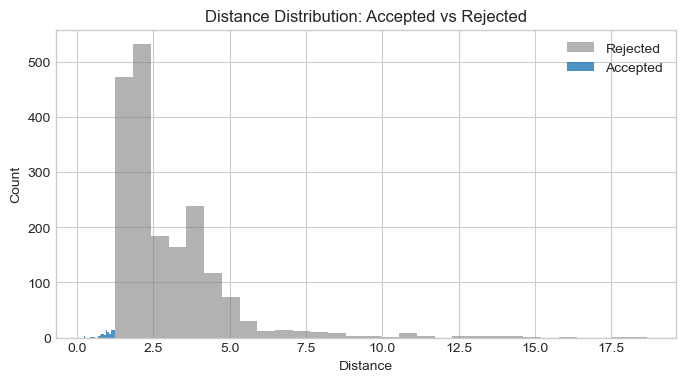

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(stage_df["stage"], stage_df["epsilon"], marker="o", color="tab:blue")
axes[0].set_title("SMC Tolerance Schedule")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Epsilon")

axes[1].plot(stage_df["stage"], stage_df["ess"], marker="o", color="tab:green")
axes[1].axhline(run_cfg["n_particles"] / 2.0, linestyle="--", color="tab:red", alpha=0.7, label="N/2")
axes[1].set_title("Effective Sample Size (ESS)")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("ESS")
axes[1].legend()

plt.tight_layout()
plt.show()

stage_df[["stage", "epsilon", "ess", "accept_rate", "simulations"]]

## 3.1 Final-Distance Check

In [ ]:
final_eps = float(stage_df["epsilon"].iloc[-1])
max_final_distance = float(particles_df["distance"].max())

print(f"Final stage epsilon: {final_eps:.6f}")
print(f"Max retained particle distance: {max_final_distance:.6f}")
print(f"Difference (max distance - epsilon): {max_final_distance - final_eps:.6e}")

Max accepted distance: 1.248774
Epsilon: 1.253870
Difference (max accepted - epsilon): -5.095648e-03
Sample ID at max accepted distance: 1032


## 4. Posterior Structure and Rejection-ABC Comparison

In [ ]:
smc_summary = smc.weighted_summary(
    particles_df[["beta", "gamma", "rho"]].to_numpy(),
    particles_df["weight"].to_numpy(),
)

rejection_path = workspace / "abc_rejection_analysis_accepted.csv"
rej_df = pd.read_csv(rejection_path)
rej_summary = {
    "mean": rej_df[["beta", "gamma", "rho"]].mean().to_numpy(),
    "std": rej_df[["beta", "gamma", "rho"]].std(ddof=0).to_numpy(),
    "q05": rej_df[["beta", "gamma", "rho"]].quantile(0.05).to_numpy(),
    "q50": rej_df[["beta", "gamma", "rho"]].quantile(0.50).to_numpy(),
    "q95": rej_df[["beta", "gamma", "rho"]].quantile(0.95).to_numpy(),
}

rows = []
for i, p in enumerate(["beta", "gamma", "rho"]):
    rows.append(
        {
            "parameter": p,
            "rej_mean": rej_summary["mean"][i],
            "smc_mean": smc_summary["mean"][i],
            "rej_std": rej_summary["std"][i],
            "smc_std": smc_summary["std"][i],
            "rej_q05": rej_summary["q05"][i],
            "smc_q05": smc_summary["q05"][i],
            "rej_q50": rej_summary["q50"][i],
            "smc_q50": smc_summary["q50"][i],
            "rej_q95": rej_summary["q95"][i],
            "smc_q95": smc_summary["q95"][i],
        }
    )

comparison_df = pd.DataFrame(rows)
comparison_df

,mean,std,5%,50%,95%
beta,0.200800,0.049637,0.120941,0.204665,0.283593
gamma,0.095808,0.022401,0.062520,0.092627,0.131568
rho,0.312959,0.077063,0.191139,0.313168,0.455956


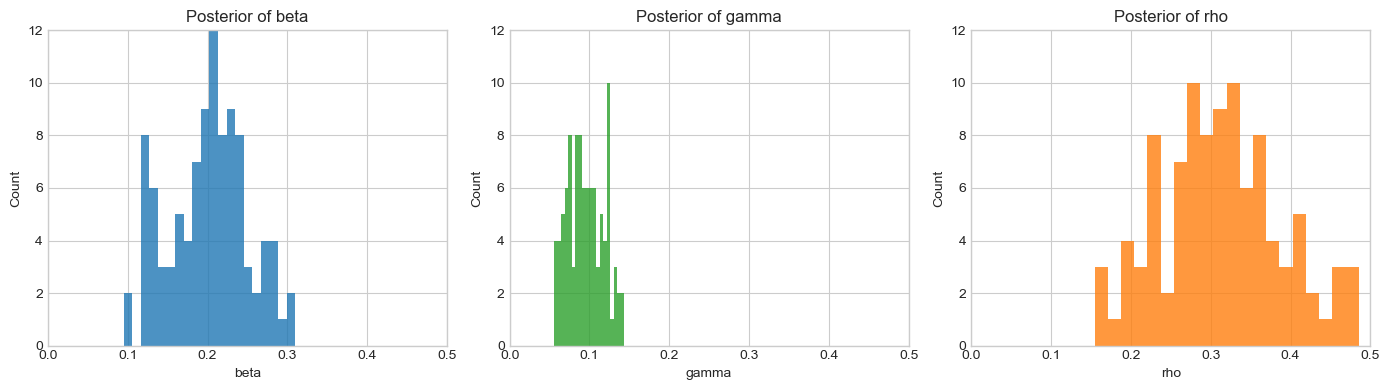

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_weights = particles_df["weight"].to_numpy() * len(particles_df)

for ax, col, color in zip(axes, ["beta", "gamma", "rho"], ["tab:blue", "tab:green", "tab:orange"]):
    ax.hist(particles_df[col], bins=20, weights=plot_weights, color=color, alpha=0.8)
    ax.set_title(f"SMC Posterior of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Weighted count")
    ax.set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

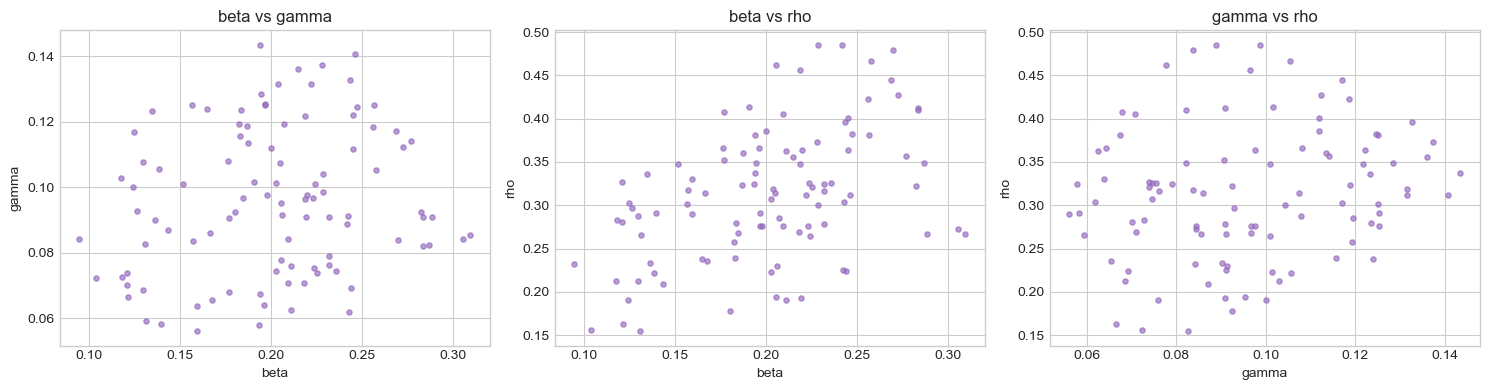

In [ ]:
pairs = [("beta", "gamma"), ("beta", "rho"), ("gamma", "rho")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (x, y) in zip(axes, pairs):
    sc = ax.scatter(
        particles_df[x],
        particles_df[y],
        s=22 + 260 * particles_df["weight"],
        c=particles_df["weight"],
        cmap="viridis",
        alpha=0.75,
        edgecolor="none",
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"SMC: {x} vs {y}")

fig.colorbar(sc, ax=axes, label="Particle weight", shrink=0.85)
plt.tight_layout()
plt.show()

## 5. Quantitative Evaluation Summary

In [ ]:
def corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.corrcoef(x, y)[0, 1])

rej_corr_br = corr(rej_df["beta"], rej_df["rho"])
smc_corr_br = corr(particles_df["beta"], particles_df["rho"])

comparison_metrics = pd.DataFrame(
    [
        {
            "metric": "beta-rho correlation",
            "Rejection_ABC": rej_corr_br,
            "SMC_ABC": smc_corr_br,
        },
        {
            "metric": "Total simulator calls",
            "Rejection_ABC": 2000.0,
            "SMC_ABC": float(total_sims),
        },
        {
            "metric": "Final tolerance",
            "Rejection_ABC": float(pd.read_csv(workspace / 'abc_rejection_analysis_distances.csv')["distance"].quantile(0.05)),
            "SMC_ABC": final_eps,
        },
    ]
)

print("Weighted SMC posterior summary:")
for i, p in enumerate(["beta", "gamma", "rho"]):
    print(
        f"{p}: mean={smc_summary['mean'][i]:.4f}, std={smc_summary['std'][i]:.4f}, "
        f"q05={smc_summary['q05'][i]:.4f}, q50={smc_summary['q50'][i]:.4f}, q95={smc_summary['q95'][i]:.4f}"
    )

print("\nComparison metrics:")
comparison_metrics